In [2]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
import statsmodels.api as sm

# Load the cleaned dataset
df = pd.read_csv("./datasets/processed_dataset.csv")

# Preview the data
df.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,...,Days Ozone,Days PM2.5,Days PM10,County Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,Cause
0,Alabama,Baldwin,2018,270,232,38,0,0,0,0,...,194,76,0,1003.0,225.0,218022,103.2,89.7,116.7,respiratory_diseases
1,Alabama,Clay,2018,110,86,24,0,0,0,0,...,0,110,0,1027.0,24.0,13275,180.8,115.8,269.0,respiratory_diseases
2,Alabama,Colbert,2018,277,235,42,0,0,0,0,...,184,93,0,1033.0,97.0,54762,177.1,143.6,216.1,respiratory_diseases
3,Alabama,DeKalb,2018,350,302,48,0,0,0,0,...,286,64,0,1049.0,111.0,71385,155.5,126.6,184.4,respiratory_diseases
4,Alabama,Elmore,2018,222,203,19,0,0,0,0,...,222,0,0,1051.0,93.0,81887,113.6,91.7,139.1,respiratory_diseases


In [3]:
# Check the variables
df.columns

Index(['State', 'County', 'Year', 'Days with AQI', 'Good Days',
       'Moderate Days', 'Unhealthy for Sensitive Groups Days',
       'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days', 'Max AQI',
       '90th Percentile AQI', 'Median AQI', 'Days CO', 'Days NO2',
       'Days Ozone', 'Days PM2.5', 'Days PM10', 'County Code', 'Deaths',
       'Population', 'Crude Rate', 'Crude Rate Lower 95% Confidence Interval',
       'Crude Rate Upper 95% Confidence Interval', 'Cause'],
      dtype='object')

In [4]:
# Summary statistics
df.describe()

,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,County Code,Deaths
count,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000
mean,2020.977412,329.594385,237.126008,87.907067,3.461439,0.845434,0.182156,0.072281,129.635528,60.445466,40.344789,0.178767,3.088416,161.974992,154.766538,9.585673,30227.776541,211.740239
std,2.003581,67.710547,70.661562,63.380046,8.670397,3.618349,1.601665,0.706093,143.063217,15.279564,9.668227,5.172511,20.844846,114.364321,123.466126,43.834727,15804.630604,338.232477
min,2018.000000,7.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1003.000000,10.000000
25%,2019.000000,342.000000,199.000000,32.000000,0.000000,0.000000,0.000000,0.000000,87.000000,52.000000,36.000000,0.000000,0.000000,75.000000,5.000000,0.000000,17113.000000,48.000000
50%,2021.000000,363.000000,239.000000,79.000000,1.000000,0.000000,0.000000,0.000000,106.000000,59.000000,41.000000,0.000000,0.000000,161.000000,162.000000,0.000000,31109.000000,109.000000
75%,2023.000000,365.000000,290.000000,132.000000,3.000000,0.000000,0.000000,0.000000,142.000000,66.000000,45.000000,0.000000,0.000000,243.000000,251.000000,0.000000,42090.500000,238.000000
max,2024.000000,366.000000,365.000000,302.000000,109.000000,69.000000,75.000000,31.000000,8368.000000,216.000000,122.000000,259.000000,365.000000,366.000000,366.000000,366.000000,56045.000000,5887.000000


**Correlation analysis**

A correlation matrix is used to examine the linear relationships between air pollution indicators and mortality variables. 

Identifier variables such as County Code and Year are removed because they do not represent measurable quantities and would distort the correlation analysis.

In [5]:
corr_df = df.drop(columns=["Year", "County Code"])
corr_df.corr(numeric_only=True)

,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,Deaths
Days with AQI,1.000000,0.504935,0.476870,0.149228,0.107643,0.056414,0.047164,0.125496,0.266658,0.282547,-0.018603,0.057277,0.132395,0.401500,0.043344,0.187489
Good Days,0.504935,1.000000,-0.504077,-0.384688,-0.260409,-0.133400,-0.045960,-0.100592,-0.518135,-0.518107,0.009441,0.091978,0.383859,-0.135893,0.116386,-0.277754
Moderate Days,0.476870,-0.504077,1.000000,0.401261,0.233973,0.099828,0.060010,0.182724,0.706859,0.778606,-0.028264,-0.040381,-0.291423,0.572382,-0.092718,0.422635
Unhealthy for Sensitive Groups Days,0.149228,-0.384688,0.401261,1.000000,0.706539,0.338609,0.121466,0.262106,0.780559,0.532704,-0.011735,-0.002065,0.057877,0.012135,0.047697,0.444573
Unhealthy Days,0.107643,-0.260409,0.233973,0.706539,1.000000,0.623921,0.165117,0.275247,0.646649,0.378082,-0.006938,-0.005927,-0.032299,0.082019,0.023161,0.360929
Very Unhealthy Days,0.056414,-0.133400,0.099828,0.338609,0.623921,1.000000,0.175419,0.196909,0.393763,0.234162,-0.003756,-0.008308,-0.021700,0.046424,0.017392,0.233944
Hazardous Days,0.047164,-0.045960,0.060010,0.121466,0.165117,0.175419,1.000000,0.623770,0.182363,0.044948,-0.003539,-0.012790,-0.055701,0.048548,0.087936,-0.000577
Max AQI,0.125496,-0.100592,0.182724,0.262106,0.275247,0.196909,0.623770,1.000000,0.307711,0.147500,-0.012946,-0.033526,-0.063209,0.098686,0.098269,0.075844
90th Percentile AQI,0.266658,-0.518135,0.706859,0.780559,0.646649,0.393763,0.182363,0.307711,1.000000,0.800738,-0.037935,-0.115573,-0.017850,0.228746,-0.126385,0.427653
Median AQI,0.282547,-0.518107,0.778606,0.532704,0.378082,0.234162,0.044948,0.147500,0.800738,1.000000,-0.096849,-0.164255,0.119089,0.171797,-0.268607,0.421905


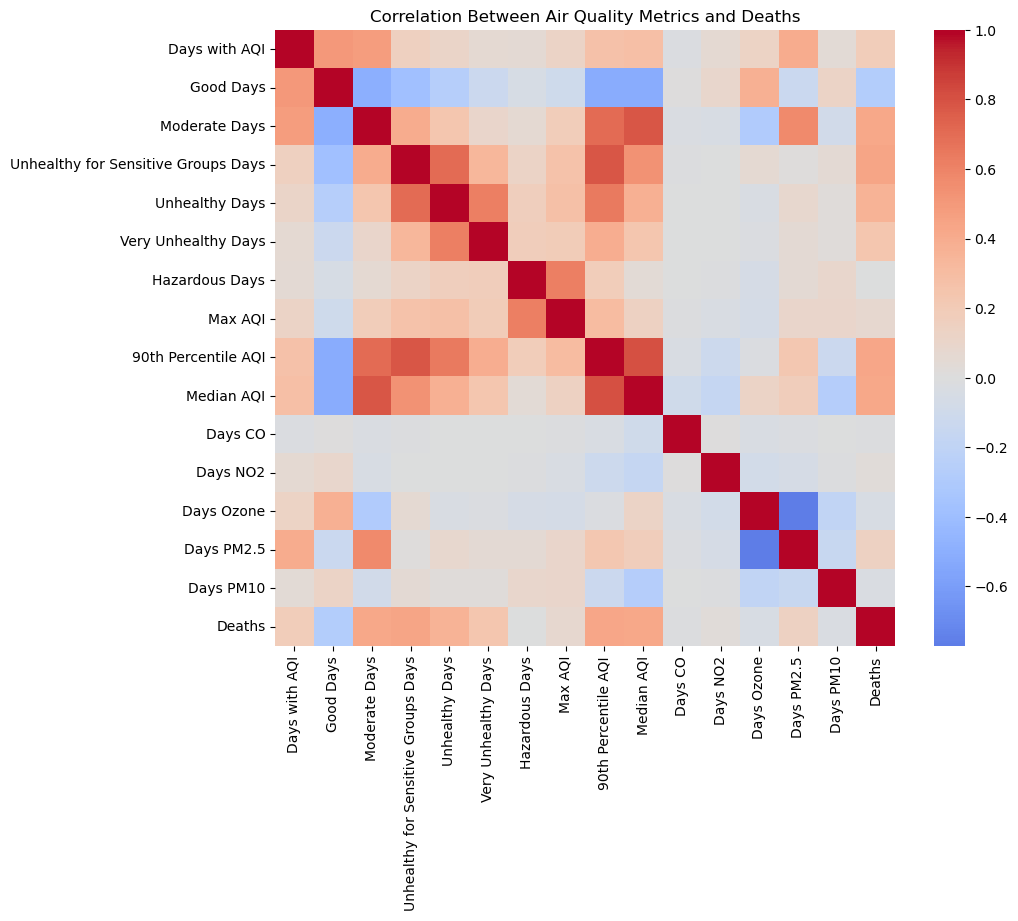

In [6]:
# Heatmap Visualization
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Air Quality Metrics and Deaths")
plt.show()    

The heatmap visualizes the strength and direction of correlations among the numeric variables. Warmer colors(red) suggests positive correlation, while cooler colors(blue) represent negative correlations. 

From this heatmap, we observe several strong positive correlations between the AQI-related variables including Median AQI, 90th Percentile AQI, Max AQI, and the number of Moderate, Unhealthy, and Very Unhealthy Days. This is expected because they measure similar aspects of air pollution severity.  

We also observe that Deaths variable show moderate positive correlations with several air quality indicators, suggesting that higher pollution levels may be associated with higher mortality. 

At the same time, the variable Good Days appears to have negative correlations with many of the pollution indicators. This makes sense because counties that experience more days with good air quality generally have fewer days with higher pollution levels.

Overall, the heatmap provides an initial look at the relationships within the dataset and suggests that worsening air quality may be linked to increases in mortality. 

**Multiple Linear Regression Model**

To formally test the relationship between air pollution and respiratory-related deaths, a multiple linear regression model is created.

Respiratory deaths serve as the dependent variable, while pollution indicators such as Median AQI, PM2.5 days, and Ozone days serve as explanatory variables. 

In [7]:
X = df[["Median AQI", "Days PM2.5", "Days Ozone"]]
y = df["Deaths"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     472.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.07e-276
Time:                        19:06:50   Log-Likelihood:                -44250.
No. Observations:                6198   AIC:                         8.851e+04
Df Residuals:                    6194   BIC:                         8.854e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -355.7031     19.045    -18.677      0.000    -393.038    -318.368
Median AQI    15.1306      0.444     34.047      0.000      14.259      16.002
Days PM2.5     0.0038      0.054      0.070      0.944      -0.103       0.110
Days Ozone    -0.2691      0.058     -4.625      0.000      -0.383      -0.155
==============================================================================
Omnibus:                     7200.233   Durbin-Watson:                   1.790
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1249546.541
Skew:                           5.901   Prob(JB):                         0.00
Kurtosis:                      71.551   Cond. No.                     1.15e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.15e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Overall, the model explains about 19% of the variation in deaths (R-squared = 0.186), which is not surprising since mortality is influenced by dozens of factors beyond just air quality. One of the key findings is that Median AQI has a strong, significant relationshps with deaths. For every one unit increase in AQI, the model predicts roughly 15 additional deaths, and this held up with extremely high statistical confidence (p < 0.001). Days with Ozone also reached the same level of significance, showing a small negative coefficient, meaning more ozone days were weakly associated with fewer deaths. 

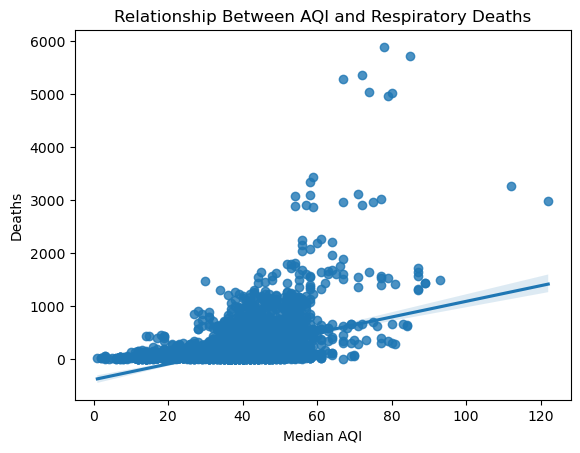

In [8]:
sns.regplot(data=df, x="Median AQI", y="Deaths")
plt.title("Relationship Between AQI and Respiratory Deaths")
plt.show()

The regression line shows an upward trend, suggesting a positive association between AQI levels and the numbers of deaths. This indicates that higher AQI levels tend to be linked with higher mortality counts. However, there appear to be some outliers, suggesting that factors beyond air quality may also influence mortality rates.

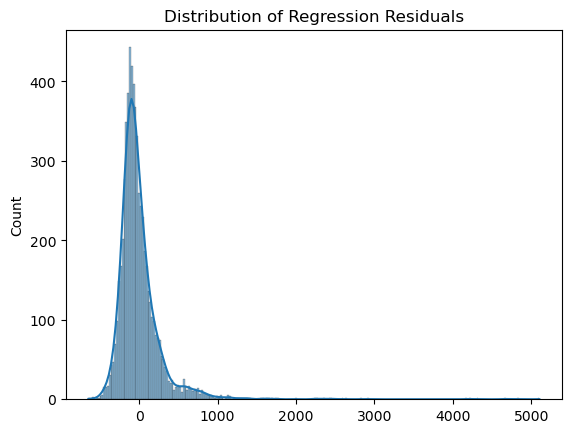

In [9]:
residuals = model.resid

sns.histplot(residuals, kde=True)
plt.title("Distribution of Regression Residuals")
plt.show()

The residual distribution is examined to evaluate whether the regression model assumptions are satisfied. Ideally, the residuals should be approximately normally distributed around zero. In this case, the residual distribution appears to be right-skewed with a long tail, suggesting that the linear regression model may not fully capture the variation in the data, possibly due to outliers or other factors influencing mortality rates.

In [12]:
# Convert needed columns to numeric
df["Crude Rate"] = pd.to_numeric(df["Crude Rate"], errors="coerce")
df["Median AQI"] = pd.to_numeric(df["Median AQI"], errors="coerce")
df["Days PM2.5"] = pd.to_numeric(df["Days PM2.5"], errors="coerce")
df["Days Ozone"] = pd.to_numeric(df["Days Ozone"], errors="coerce")

# Keep only complete rows for this model
rate_df = df.dropna(subset=["Crude Rate", "Median AQI", "Days PM2.5", "Days Ozone"]).copy()

print(rate_df[["Crude Rate", "Median AQI", "Days PM2.5", "Days Ozone"]].dtypes)
print(rate_df.shape)

Crude Rate    float64
Median AQI      int64
Days PM2.5      int64
Days Ozone      int64
dtype: object
(6174, 25)


In [ ]:
# Model 1: Regress raw respiratory death counts on air quality variables 
# to see how pollution measures relate to total deaths across county-year observations.
import statsmodels.formula.api as smf

model = smf.ols(
    formula='Deaths ~ Q("Median AQI") + Q("Days PM2.5") + Q("Days Ozone")',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Deaths   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     472.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.07e-276
Time:                        19:37:11   Log-Likelihood:                -44250.
No. Observations:                6198   AIC:                         8.851e+04
Df Residuals:                    6194   BIC:                         8.854e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        -355.7031     19.045    -

In [20]:
# Model 2: Regress crude respiratory mortality rate on air quality variables so counties 
# are compared after adjusting for population size rather than raw death totals.
rate_model = smf.ols(
    formula='Q("Crude Rate") ~ Q("Median AQI") + Q("Days PM2.5") + Q("Days Ozone")',
    data=rate_df
).fit()

print(rate_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Q("Crude Rate")   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     121.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.04e-76
Time:                        19:38:01   Log-Likelihood:                -31406.
No. Observations:                6174   AIC:                         6.282e+04
Df Residuals:                    6170   BIC:                         6.285e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         144.3072      2.446     

In [ ]:
# Model 3: Regress crude respiratory mortality rate on air quality variables while also
#  controlling for year fixed effects to account for national time trends and year-specific shocks.
year_fe_model = smf.ols(
    formula='Q("Crude Rate") ~ Q("Median AQI") + Q("Days PM2.5") + Q("Days Ozone") + C(Year)',
    data=rate_df
).fit()

print(year_fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Q("Crude Rate")   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     47.38
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           2.89e-83
Time:                        19:38:28   Log-Likelihood:                -31377.
No. Observations:                6174   AIC:                         6.277e+04
Df Residuals:                    6164   BIC:                         6.284e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         151.6661      2.721     

In [ ]:
# Extract only the main pollution coefficients from the county and year 
# fixed effects model so the key results are easier to interpret.
county_year_fe_model.params[[
    'Q("Median AQI")',
    'Q("Days PM2.5")',
    'Q("Days Ozone")'
]]

Q("Median AQI")   -0.118228
Q("Days PM2.5")   -0.007637
Q("Days Ozone")   -0.016982
dtype: float64

In [24]:
# Extract the p-values for the main pollution coefficients from the county
#  and year fixed effects model to check which predictors remain statistically significant.
county_year_fe_model.pvalues[[
    'Q("Median AQI")',
    'Q("Days PM2.5")',
    'Q("Days Ozone")'
]]

Q("Median AQI")    0.072509
Q("Days PM2.5")    0.320481
Q("Days Ozone")    0.040695
dtype: float64

In [ ]:
# Compare model fit across the original and added regressions
#  to see how the results change as we add population adjustment and fixed effects.
model_comparison = pd.DataFrame({
    "Model": [
        "Raw Deaths",
        "Crude Rate",
        "Crude Rate + Year FE",
        "Crude Rate + County FE + Year FE"
    ],
    "R-squared": [
        model.rsquared,
        rate_model.rsquared,
        year_fe_model.rsquared,
        county_year_fe_model.rsquared
    ],
    "Adj. R-squared": [
        model.rsquared_adj,
        rate_model.rsquared_adj,
        year_fe_model.rsquared_adj,
        county_year_fe_model.rsquared_adj
    ]
})

model_comparison

,Model,R-squared,Adj. R-squared
0,Raw Deaths,0.186367,0.185973
1,Crude Rate,0.055960,0.055501
2,Crude Rate + Year FE,0.064701,0.063336
3,Crude Rate + County FE + Year FE,0.872060,0.848267


To strengthen our analysis, we estimated several additional regression models beyond the original pooled OLS model. The original model used raw respiratory death counts as the outcome variable, which can be heavily influenced by county population size. To account for this, we re-estimated the model using crude respiratory mortality rate, which normalizes deaths relative to county population and allows for more meaningful comparisons across counties.

We then added year fixed effects to control for broad year-to-year differences that could affect mortality across all counties, such as national health trends, reporting changes, or unusual events in a given year. Finally, we added county fixed effects to control for stable county-level characteristics, such as long-run demographic composition, healthcare access, geography, and other persistent structural differences.

These additional models were used as robustness checks to test whether the original relationship between air quality and respiratory mortality remained consistent under more careful specifications. The results showed that the initial positive relationship observed in the raw-deaths model weakened substantially after adjusting for population size and fixed effects. In the final county and year fixed effects model, most pollution variables were no longer strongly statistically significant, with only ozone remaining weakly significant.

Overall, these findings suggest that the simple positive association in the original model was sensitive to model specification. Much of the variation in respiratory mortality appears to be explained by persistent county-level differences and year effects rather than by the pollution variables alone. This means pollution may still play a role, but its relationship with respiratory mortality in this dataset is weaker and less consistent once broader structural factors are taken into account.